In [1]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes.tree.tree import BinomialTree
from black_scholes.closed import BlackScholes

from config.plot_settings import *

In [2]:
r = 0.1
sigma = 0.3
K = 1.0
T = 1.0

american_tree_put = BinomialTree(K=K, r=r, sigma=sigma, T=T, n_steps=500, option_type="put", exercise_type="american")
european_tree_put = BinomialTree(K=K, r=r, sigma=sigma, T=T, n_steps=500, option_type="put", exercise_type="european")
black_scholes_put = BlackScholes(K=K, r=r, sigma=sigma, T=T, option_type="put")

american_tree_call = BinomialTree(K=K, r=r, sigma=sigma, T=T, n_steps=500, option_type="call", exercise_type="american")
european_tree_call = BinomialTree(K=K, r=r, sigma=sigma, T=T, n_steps=500, option_type="call", exercise_type="european")
black_scholes_call = BlackScholes(K=K, r=r, sigma=sigma, T=T, option_type="call")

In [3]:
# European vs American vs Intrinsic

Ss = np.linspace(0.6, 1.5, 100)
t = 0

put_price_am = american_tree_put.predict(t, Ss)
put_price_eu = european_tree_put.predict(t, Ss)
put_price_bs = black_scholes_put.price(t, Ss)

call_price_am = american_tree_call.predict(t, Ss)
call_price_eu = european_tree_call.predict(t, Ss)
call_price_bs = black_scholes_call.price(t, Ss)

intrinsic_put = np.maximum(K - Ss, 0)
intrinsic_call = np.maximum(Ss - K, 0)


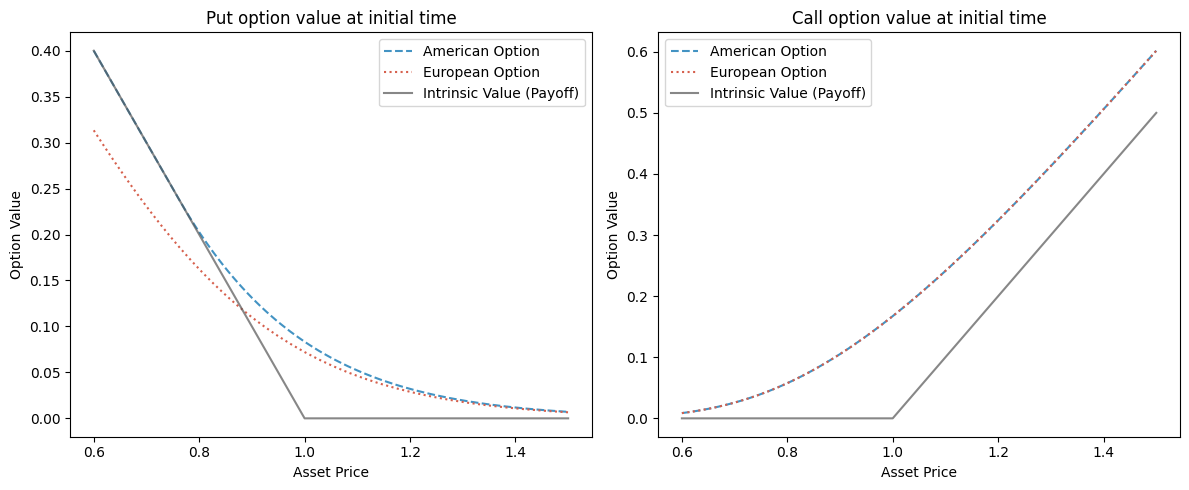

In [4]:
plt.figure(figsize=figsize2)

plt.subplot(1, 2, 1)
plt.plot(Ss, put_price_am, label='American Option', linestyle="--")
plt.plot(Ss, put_price_eu, label='European Option', linestyle=':')
plt.plot(Ss, intrinsic_put, label='Intrinsic Value (Payoff)', linestyle='-', alpha=0.7)
plt.title('Put option value at initial time')
plt.xlabel('Asset Price')
plt.ylabel('Option Value')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Ss, call_price_am, label='American Option', linestyle="--")
plt.plot(Ss, call_price_eu, label='European Option', linestyle=':')
plt.plot(Ss, intrinsic_call, label='Intrinsic Value (Payoff)', linestyle='-', alpha=0.7)
plt.title('Call option value at initial time')
plt.xlabel('Asset Price')
plt.ylabel('Option Value')
plt.legend()

plt.tight_layout()
plt.savefig("../../plots/introduction/put_call_values.png")
plt.show()